In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("student_productivity_distraction_dataset_20000.csv")

In [3]:
df

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [5]:
df.dtypes

student_id                 int64
age                        int64
gender                    object
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level               int64
focus_score                int64
final_grade              float64
productivity_score       float64
dtype: object

In [6]:
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


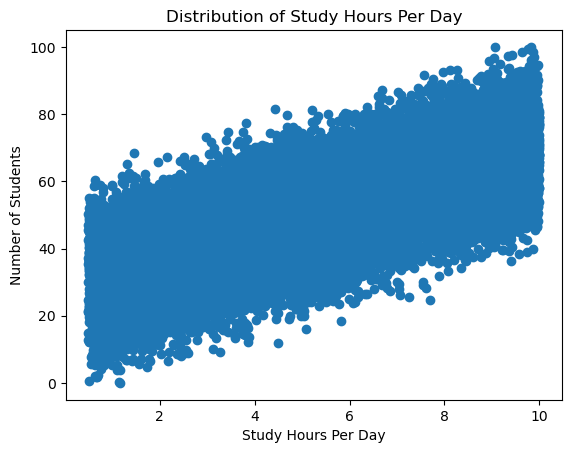

In [14]:
plt.figure()
plt.scatter(df['study_hours_per_day'], df['productivity_score'])
plt.title("Distribution of Study Hours Per Day")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Number of Students")
plt.show()

In [17]:
X = df[['study_hours_per_day',
        'phone_usage_hours',
        'sleep_hours',
        'stress_level',
        'exercise_minutes',
        'assignments_completed',
        'attendance_percentage']]

y = df['productivity_score']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (16000, 7)
Testing size: (4000, 7)


In [20]:
# Linear Regrassion

from sklearn.linear_model import LinearRegression

l = LinearRegression()
l.fit(X_train, y_train)

l_pred = l.predict(X_test)

In [21]:
from sklearn.ensemble import RandomForestRegressor

r = RandomForestRegressor()
r.fit(X_train, y_train)

r.pred = r.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(true, predicted, model_name):
    print(f"\n{model_name} Performance:")
    print("MAE:", mean_absolute_error(true, predicted))
    print("MSE:", mean_squared_error(true, predicted))
    print("RMSE:", np.sqrt(mean_squared_error(true, predicted)))
    print("R2 Score:", r2_score(true, predicted))

In [25]:
evaluate_model(y_test, l_pred, "Linear Regression")
evaluate_model(y_test, r.pred, "Random Forest")


Linear Regression Performance:
MAE: 5.594136982019265
MSE: 41.79832144767407
RMSE: 6.465162136224742
R2 Score: 0.8377336966856324

Random Forest Performance:
MAE: 5.805557950000001
MSE: 46.711786370375
RMSE: 6.834602136948061
R2 Score: 0.8186590122998109


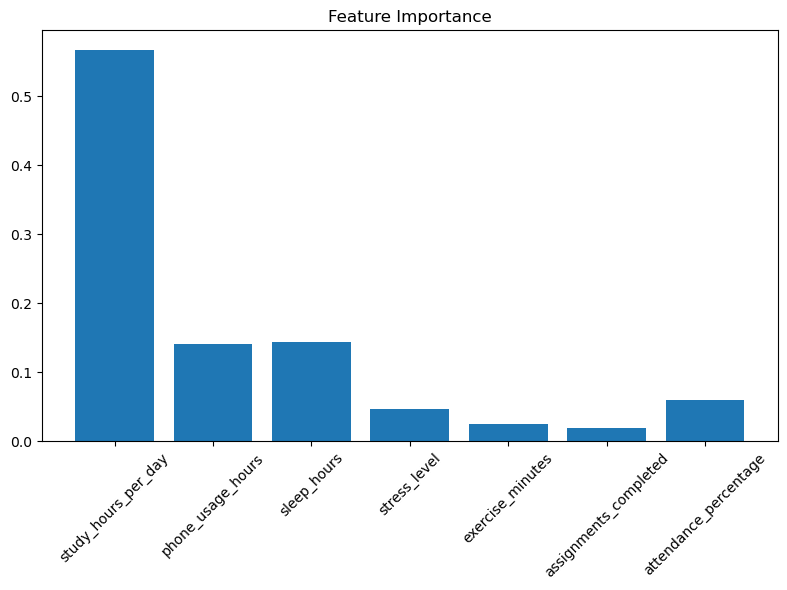

In [28]:
importances = r.feature_importances_

plt.figure(figsize=(8,6))
plt.bar(X.columns, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()